In [6]:
from pathlib import Path
import pandas as pd
import woodsort.nwb as nwb 
import pynapple as nap
import spikeinterface.full as si
import warnings
import neuroconv.tools.spikeinterface as nc
import neuroconv

In [7]:
### SPECIFY PATHS ### 

data_path = Path('/home/avadher/Data/Anna/')
session_name = 'H7408-250821'
meta_name = 'H7400_metadata.xlsx'
sorter = 'mountainsort5'
#sorter = 'kilosort4'
analyzer_name = session_name + "_analyzer_" + sorter
analyzer_path = data_path / session_name / analyzer_name
#nwb_path = data_path / 'NWB' / session_name 
nwb_path = data_path / 'Temp' / session_name
nwb_name = session_name + '_' + sorter

#nwb_path = data_path / "NWB" / f"{session_name}-{sorter}"
sleep_path = data_path / session_name / 'Sleep'

session_path = list(data_path.rglob(session_name))[0]

# Ignore annoying warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


In [8]:
### LOAD DATA ###

metadata = nwb.io.read_metadata_excel(data_path / meta_name, session_name, print_output=True)
start_time = nwb.io.get_start_time(session_path)

# load stuff 
tracking = pd.read_csv(session_path / 'TrackingProcessed.csv',index_col=0, header=0)
pos = nap.TsdFrame(tracking[["x", "y"]])
hd = nap.Tsd(tracking['hd'])
epochs = pd.read_csv(session_path / 'EpochTimestamps.csv', header=0)
track_dist = nwb.io.get_matlab_trackdistance(session_path / 'TrackDistance.mat', vbl_name='trackdist')

# add probe 
analyzer = si.load_sorting_analyzer(analyzer_path)


{'epoch': {'1': 'sleep1',
           '2': 'cueone1',
           '3': 'sleep2',
           '4': 'cueone2',
           '5': 'sleep3',
           '6': 'cuetwo1',
           '7': 'sleep4',
           '8': 'bothcues1'},
 'file': {'experiment_description': 'Place cell recordings',
          'experimenter': 'Rastedt, Anna',
          'institution': 'University of Edinburgh',
          'lab': 'Wood/Dudchenko lab',
          'name': 'H7408-250821',
          'notes': 'protocol_v3',
          'protocol': 'session1',
          'session_description': 'Novel linear track with distal visual and local cue '
                                 'manipulations'},
 'probe': [{'description': '6x10-channels, implanted along the AP axis. Channels sorted top to '
                           'bottom of shank.',
            'id': 1,
            'location': 'right CA1',
            'nshanks': 6.0,
            'step': 20.0,
            'type': 'Neuronexus Buzsaki64sp probe'}],
 'subject': {'dob': 250531.0,
         

In [12]:
### NWB ### 

#Create NWB file
nwbfile = nwb.convert.create_nwb_file(metadata, start_time)

# Add units
nwbfile = nwb.convert.add_spikeinterface_openephys(nwbfile, analyzer, merging_mode='soft')

# Add tracking
nwbfile = nwb.convert.add_tracking(nwbfile, pos, hd)

# Add track distance 
nwbfile = nwb.convert.add_misc_tsd(nwbfile, track_dist, name='track_distance', description='Position along the track', unit='cm')

# Add epochs
nwbfile = nwb.convert.add_epochs(nwbfile, epochs, metadata)

# Add sleep scoring and pseudo EMG
nwbfile = nwb.convert.add_sleep(nwbfile, sleep_path, session_name)

# Save NWB file
nwbfile = nwb.convert.save_nwb_file(nwbfile, nwb_path, nwb_name)

# Load to check
rec = nwb.convert.load_nwb_file(nwb_path, nwb_name)

# print units table
print(rec['units']) 

units = rec['units']

Creating NWB file and adding metadata...

Adding SpikeInterface units and metrics to the NWB file...

Applying curation from file /home/avadher/Data/Anna/H7408-250821/H7408-250821_analyzer_mountainsort5/spikeinterface_gui/curation_data.json
Adding tracking to NWB file...
Adding 'track_distance' to the NWB file...
Adding epochs to NWB file...
Adding sleep stages to NWB file...
Adding pseudoEMG to the NWB file...
Saving NWB file...


OSError: Unable to synchronously create file (unable to truncate a file which is already open)

['_AbstractContainer__children', '_AbstractContainer__container_source', '_AbstractContainer__field_values', '_AbstractContainer__fieldsconf', '_AbstractContainer__gather_fields', '_AbstractContainer__modified', '_AbstractContainer__name', '_AbstractContainer__obj', '_AbstractContainer__object_id', '_AbstractContainer__parent', '_AbstractContainer__read_io', '_Data__data', '__abstractmethods__', '__bool__', '__class__', '__del__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__fields__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_check_field_spec', '_check_field_spec_keys', '_data_type_attr', '_experimental', '_field_config', '_fieldsname', '_get_fields', '_get_type_map', '_getter', '_in_construct_mode', '

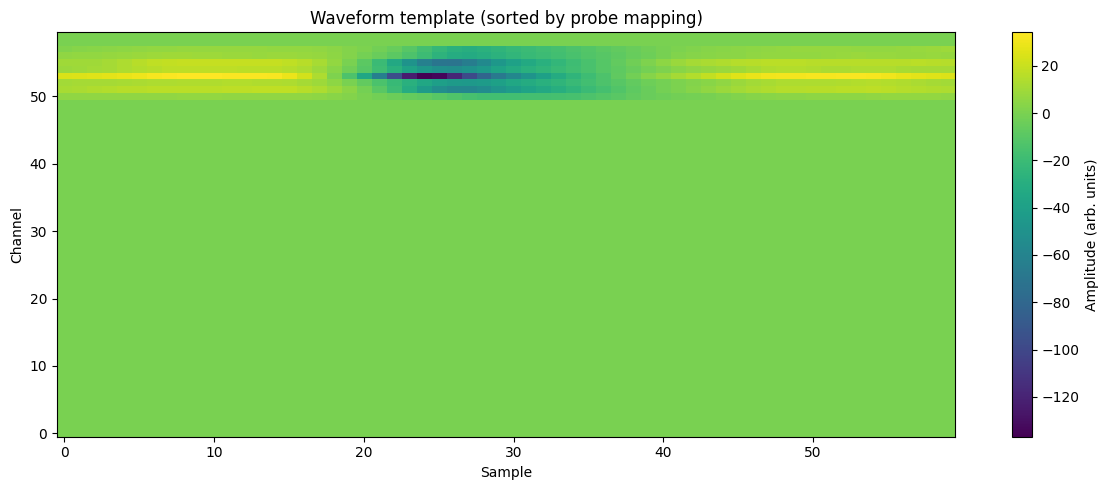

In [5]:
import matplotlib.pyplot as plt
import numpy as np 


### GET ANATOMICALLY SORTED WAVEFORMS FROM NWB ### 
units_tsgroup = rec['units']
# get electrodes table 
electrodes_table = rec.nwb.electrodes.to_dataframe() # electrode_name is anatomical index (top-bottom shank-wise) 
#electrodes_table['electrode_name'] = electrodes_table['electrode_name'].astype(int) # make sure it's int - SpikeInterface sometimes turns them to strings
electrodes_table['channel_name'] = electrodes_table['channel_name'].str.replace('CH', '', regex=False).astype(int) - 1 # now channel_name is the dat file channel index (0-based)
# To sort the waveform anatomically by shank and then by the y coordinate
electrodes_table = electrodes_table.sort_values(by=['aggregation_key', 'rel_y'], ascending=[True, False])
sort_ix = electrodes_table.index.to_numpy().astype(int) # use index to sort waveforms anatomically 

# load waveform 
print(dir(rec.nwb.units['waveform_mean']))
cell_number = 22 # cell 75 is obvious to track down 
waveforms = rec.nwb.units['waveform_mean']
waveforms = np.asarray(waveforms)
wf = waveforms[cell_number,:,sort_ix] # waveforms are arranged according to a cryptic device_contact_index in SpikeInterface that gets propagated as index here

# plot waveform - it should be spatially localized 
plt.figure(figsize=(12, 5))
im = plt.imshow(wf, aspect="auto", origin="lower")
plt.ylabel("Channel")
plt.xlabel("Sample")
plt.title("Waveform template (sorted by probe mapping)")
plt.colorbar(im, label="Amplitude (arb. units)")
plt.tight_layout()
plt.show()

In [10]:
# Load to check
rec = nwb.convert.load_nwb_file(nwb_path, nwb_name)

# print units table
print(rec['units']) 

H7408-250821_mountainsort5
┍━━━━━━━━━━━━━━━━┯━━━━━━━━━━━━━┑
│ Keys           │ Type        │
┝━━━━━━━━━━━━━━━━┿━━━━━━━━━━━━━┥
│ units          │ TsGroup     │
│ sleep_stages   │ IntervalSet │
│ epochs         │ IntervalSet │
│ track_distance │ Tsd         │
│ pseudoEMG      │ Tsd         │
│ position       │ TsdFrame    │
│ head-direction │ Tsd         │
┕━━━━━━━━━━━━━━━━┷━━━━━━━━━━━━━┙
Index    rate      unit_name    quality    aggregation_key    coord_est_x    ...
-------  --------  -----------  ---------  -----------------  -------------  -----
0        15.04258  0            good       0                  -9.49068       ...
1        11.00783  1            good       1                  149.54387      ...
2        5.8323    2            good       2                  313.47799      ...
3        2.6546    3            good       2                  318.22429      ...
4        8.82186   4            good       3                  484.64458      ...
5        1.77794   5            good     